Calculating predictions for the Final Optimized Model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


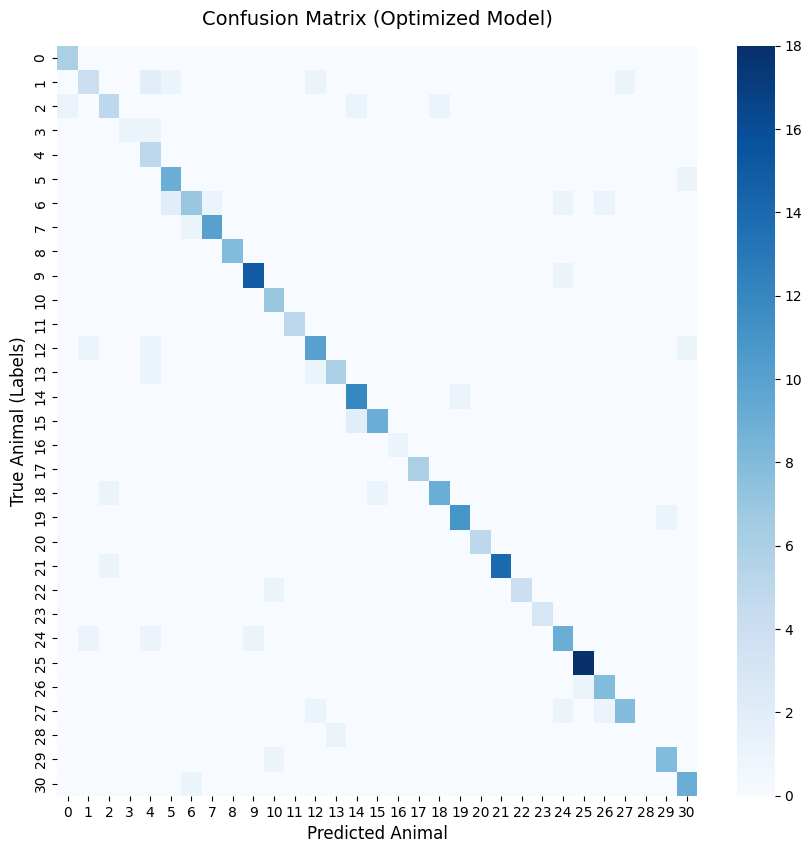


Confusion matrix creation complete.


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Calculating predictions for the Final Optimized Model...")

# 1. Get predictions from your model
y_pred_new = optimized_model.predict(X_test)

y_pred_classes_new = np.argmax(y_pred_new, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Create the Confusion Matrix
cm_new = confusion_matrix(y_true_classes, y_pred_classes_new)


plt.figure(figsize=(10, 10))
sns.heatmap(cm_new, annot=False, cmap='Blues', fmt='g')

plt.title('Confusion Matrix (Optimized Model)', fontsize=14, pad=15)
plt.xlabel('Predicted Animal', fontsize=12)
plt.ylabel('True Animal (Labels)', fontsize=12)


plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.9)
plt.show()

print("\nConfusion matrix creation complete.")

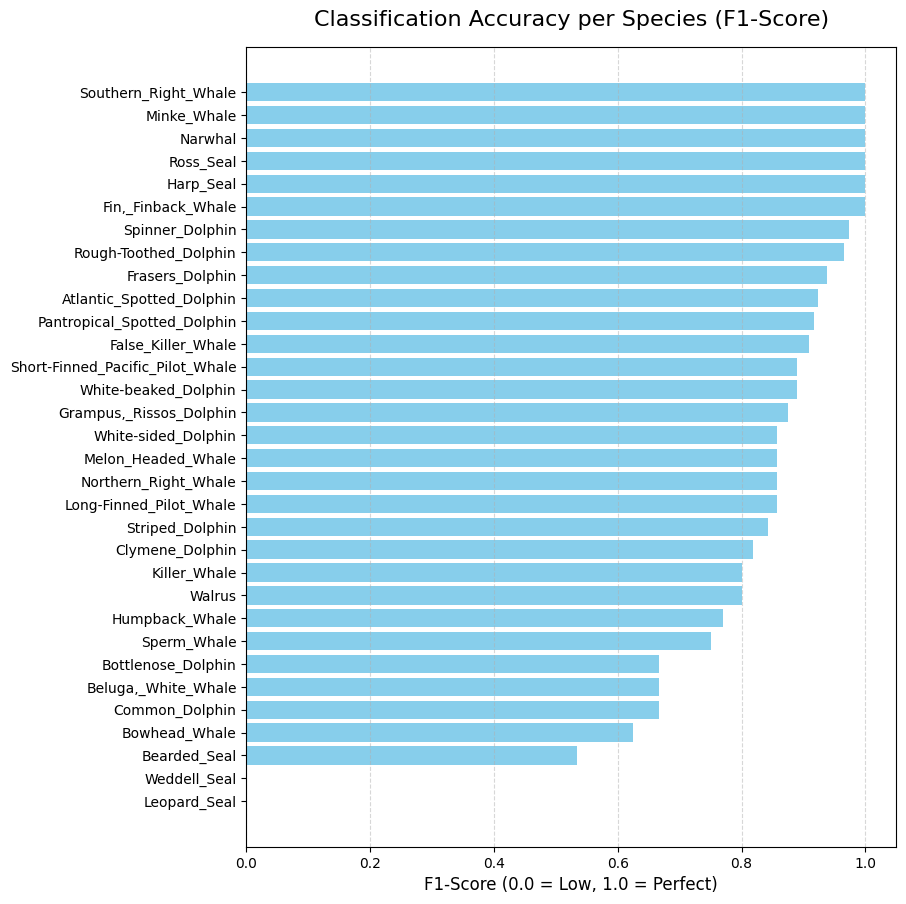


Performance visualization complete. Ready for presentation.


In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the data
report_dict = classification_report(
    y_true_classes, y_pred_classes_new, 
    labels=all_labels, target_names=animal_names, 
    zero_division=0, output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
df_animals = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# 2. Clean the ghost label and Sort
if 'data' in df_animals.index:
    df_animals = df_animals.drop('data')
df_animals = df_animals.sort_values(by='f1-score', ascending=True)


plt.figure(figsize=(10, 10))
plt.barh(df_animals.index, df_animals['f1-score'], color='skyblue')

plt.title('Classification Accuracy per Species (F1-Score)', fontsize=16, pad=15)
plt.xlabel('F1-Score (0.0 = Low, 1.0 = Perfect)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.subplots_adjust(left=0.3, bottom=0.1, right=0.95, top=0.9)
plt.show()

print("\nPerformance visualization complete. Ready for presentation.")

In [68]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Define paths 
base_path = r"C:\Users\CHANGE ME\Desktop\Vaquita_Acoustic_Monitoring_AI"
data_path = os.path.join(base_path, "data")

X = []  
y = []  

print("Starting to load MFCC images into memory...")

# 2. Scan and read .png images
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith("_mfcc.png"):
            img_path = os.path.join(root, file)
            
            try:
                # Read image in grayscale
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                # Resize to ensure all images have the same dimensions
                img_resized = cv2.resize(img, (64, 64))
                
                # Check for "data" folder in path to avoid ghost labels
                folder_name = os.path.basename(root)
                if folder_name != "data":
                    X.append(img_resized)
                    y.append(folder_name)
                
            except Exception as e:
                print(f"Error reading image {file}: {e}")

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# 3. Normalization: Scale pixels from 0-255 to 0-1
X = X / 255.0
X = np.expand_dims(X, axis=-1)  # Add channel dimension

# 4. Encode animal names to numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Save the exact number of classes
num_classes = len(label_encoder.classes_)

# 5. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"\n[SUCCESS] Loaded a total of {len(X)} images!")
print(f"Training Data: {X_train.shape[0]} images")
print(f"Test Data: {X_test.shape[0]} images")
print(f"Total Animal Species identified: {num_classes}")

Starting to load MFCC images into memory...

[SUCCESS] Loaded a total of 1357 images!
Training Data: 1085 images
Test Data: 272 images
Total Animal Species identified: 32


In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Building the Final Custom AI")

# The architecture that won all experiments
optimized_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')
])

optimized_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# The early stopping callback
early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=5,             
    restore_best_weights=True 
)

print("Starting training...")

# Training process
history_opt = optimized_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

print("\n[SUCCESS] The Champion model is now in memory!")

Building the Final Custom AI
Starting training...
Epoch 1/50


c:\Users\CHANGE ME\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.0424 - loss: 3.4345 - val_accuracy: 0.0662 - val_loss: 3.4097
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.0618 - loss: 3.3934 - val_accuracy: 0.0662 - val_loss: 3.3773
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.0710 - loss: 3.3000 - val_accuracy: 0.0846 - val_loss: 3.1806
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.1539 - loss: 3.0077 - val_accuracy: 0.2279 - val_loss: 2.8350
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2120 - loss: 2.7424 - val_accuracy: 0.3088 - val_loss: 2.5042
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2885 - loss: 2.3970 - val_accuracy: 0.3934 - val_loss: 2.2527
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3834 - loss: 2.1579 - val_accuracy: 0.4559 - val_loss: 1.9346
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4562 - loss: 1.9121 - val_accuracy: 0.5110 - val_loss: 1.